# 02 - Data Cleaning Notebook
This notebook performs step-by-step cleaning, validation, and feature derivation for the coffee sales dataset using reusable functions from `src/`.

**Last updated:** 2026-03-29

## Environment Setup

Resolve the project root and add `src/` to `sys.path` so all modules in `src/` are importable without installation. The candidate-roots approach works both locally (run from `notebooks/`) and on Kaggle (run from a different working directory).

In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((p for p in candidate_roots if (p / 'src').exists()), Path.cwd())
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

project_root

WindowsPath('c:/Users/Admin/project/Data Analysis/coffee-sales-analysis')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from cleaning.clean_data import clean_sales_data
from config import settings
from features.time_features import derive_time_features
from ingestion.load_data import load_raw_sales_data
from validation.schema import assert_valid_dataset, summarize_validation

## Load Raw Data

Load the original, unmodified CSV from `data/raw/` via `src/ingestion/load_data.py`. The raw data is treated as immutable — no writes are made to this directory.

In [3]:
raw_df = load_raw_sales_data()
raw_df.shape

(3547, 11)

In [4]:
raw_df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [5]:
raw_df.dtypes.to_frame('dtype')

,dtype
hour_of_day,int64
cash_type,str
money,float64
coffee_name,str
Time_of_Day,str
Weekday,str
Month_name,str
Weekdaysort,int64
Monthsort,int64
Date,str


## Raw Data Validation Check

Run schema validation on the raw DataFrame before any cleaning. This documents baseline data quality — confirming row count, required columns, missing-value counts, and value-range issues — so that cleaning impact can be compared afterwards.

In [6]:
raw_validation = summarize_validation(raw_df)
pd.DataFrame({'metric': raw_validation.keys(), 'value': raw_validation.values()})

,metric,value
0,rows,3547
1,columns,11
2,is_valid,True
3,errors,[]


## Cleaning Execution

Pass the raw DataFrame through `clean_sales_data` from `src/cleaning/clean_data.py`. This function applies all transformations in sequence:

- Strips and normalises column names and string values.
- Coerces numeric fields (`money`, `hour_of_day`, `Weekdaysort`, `Monthsort`) with error coercion.
- Parses `Date` to ISO date format and `Time` to `HH:MM:SS`.
- Repairs invalid or absent `Time_of_Day` values by re-bucketing from `hour_of_day`.
- Imputes missing `Weekday`, `Weekdaysort`, `Month_name`, and `Monthsort` from the `Date` column.
- Drops rows missing any critical column (`money`, `coffee_name`, `Date`, `Time`) and rows where `money < 0`.
- Removes duplicate rows and sorts chronologically by `Date` then `Time`.

In [7]:
cleaned_df = clean_sales_data(raw_df, drop_duplicates=True)
cleaned_df.shape

(3547, 11)

In [8]:
cleaning_report = pd.DataFrame(
    {
        'rows_raw': [len(raw_df)],
        'rows_cleaned': [len(cleaned_df)],
        'rows_removed': [len(raw_df) - len(cleaned_df)],
        'duplicates_raw': [int(raw_df.duplicated().sum())],
        'duplicates_cleaned': [int(cleaned_df.duplicated().sum())],
    }
)
cleaning_report

,rows_raw,rows_cleaned,rows_removed,duplicates_raw,duplicates_cleaned
0,3547,3547,0,0,0


In [9]:
null_summary = cleaned_df.isna().sum().sort_values(ascending=False).to_frame('null_count')
null_summary

,null_count
hour_of_day,0
cash_type,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0


## Post-Cleaning Validation

Re-run the same schema validation on the cleaned DataFrame. The validation summary should show zero nulls in critical columns and all value ranges within spec. Any assertion error here indicates a cleaning step that needs attention.

In [10]:
assert_valid_dataset(cleaned_df)
cleaned_validation = summarize_validation(cleaned_df)
pd.DataFrame({'metric': cleaned_validation.keys(), 'value': cleaned_validation.values()})

,metric,value
0,rows,3547
1,columns,11
2,is_valid,True
3,errors,[]


## Time Feature Derivation

Enrich the cleaned DataFrame with additional time-dimension columns via `derive_time_features` in `src/features/time_features.py`. New columns added include `transaction_datetime`, `day_of_month`, `week_of_year`, `is_weekend`, `weekday_number`, and `month_number`. These features support the aggregations and heatmaps in `03_analysis.ipynb`.

In [11]:
featured_df = derive_time_features(cleaned_df)
featured_df.shape

(3547, 17)

In [12]:
new_columns = sorted(set(featured_df.columns) - set(cleaned_df.columns))
new_columns

['day_of_month',
 'is_weekend',
 'month_number',
 'transaction_datetime',
 'week_of_year',
 'weekday_number']

In [13]:
featured_df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,transaction_datetime,day_of_month,week_of_year,is_weekend,weekday_number,month_number
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50,2024-03-01 10:15:50,1,9,False,5,3
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22,2024-03-01 12:19:22,1,9,False,5,3
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18,2024-03-01 12:20:18,1,9,False,5,3
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33,2024-03-01 13:46:33,1,9,False,5,3
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14,2024-03-01 13:48:14,1,9,False,5,3


## Save Cleaned Dataset

Persist the feature-enriched DataFrame to `data/processed/coffee_sales_processed.csv`. This file is the single source-of-truth consumed by `03_analysis.ipynb` and by `main.py`. The output directory is resolved from `settings` in `src/config.py` — no paths are hardcoded here.

In [14]:
settings.processed_data_dir.mkdir(parents=True, exist_ok=True)
processed_output_path = settings.processed_data_dir / 'coffee_sales_processed.csv'
featured_df.to_csv(processed_output_path, index=False)
processed_output_path

WindowsPath('C:/Users/Admin/project/Data Analysis/coffee-sales-analysis/data/processed/coffee_sales_processed.csv')

## Cleaning Impact Visualization

A simple bar chart comparing row count before and after cleaning gives an at-a-glance view of how many rows (if any) were removed by the cleaning pipeline. In a clean dataset this will show identical bars, confirming that no data was lost unnecessarily.

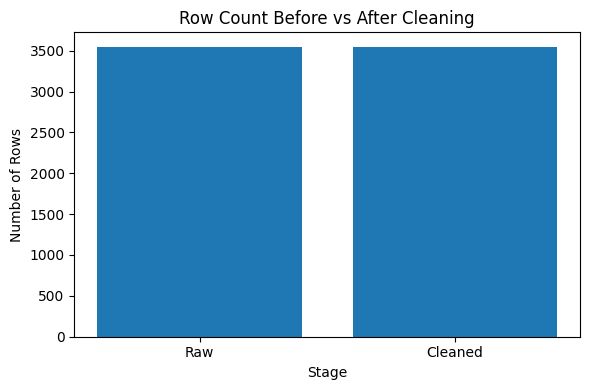

In [15]:
comparison = pd.DataFrame({'stage': ['Raw', 'Cleaned'], 'rows': [len(raw_df), len(cleaned_df)]})

plt.figure(figsize=(6, 4))
plt.bar(comparison['stage'], comparison['rows'])
plt.title('Row Count Before vs After Cleaning')
plt.xlabel('Stage')
plt.ylabel('Number of Rows')
plt.tight_layout()
plt.show()

## Transformation Log
The cleaning steps are executed by `clean_sales_data` in `src/cleaning/clean_data.py`.

Applied transformations:
- Normalized and stripped column names and string values.
- Coerced numeric fields (`money`, `hour_of_day`, `Weekdaysort`, `Monthsort`).
- Parsed `Date` and `Time` into consistent formats.
- Repaired invalid or missing `Time_of_Day`, `Weekday`, and `Month_name` values where derivable.
- Dropped rows with missing critical columns and rows with negative `money`.
- Removed duplicate rows and sorted by `Date` and `Time`.

Additional time features are added by `derive_time_features` in `src/features/time_features.py`.

## Summary
This notebook produced a validated, cleaned dataset and enriched it with reusable time features.

Key outcomes:
- Raw data loaded via `src/ingestion/load_data.py` and checked with validation utilities.
- Cleaning was performed through `src/cleaning/clean_data.py` with no inline transformation logic.
- Post-cleaning validation passed using `assert_valid_dataset`.
- Final cleaned dataset was saved to `data/processed/coffee_sales_processed.csv`.

This keeps the workflow reproducible and aligned with project notebook and code-organization rules.